# Решение уравнения Курамото-Сивашинского

Уравнение Курамото-Сивашинского:
$$u_t + uu_x + u_{xx} + \sigma u_{xxx} + u_{xxxx} = 0$$

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ellipj
from IPython.display import display, Math

In [ ]:
# Утилиты

def show_math(latex_str):
    display(Math(latex_str))

def format_sol_dict(sol_dict, keys_to_show=None):
    """Превращает словарь коэффициентов в строку LaTeX"""
    if keys_to_show is None:
        def sort_logic(k):
            s = str(k)
            if s.startswith('A'): return (0, s)
            if s in ['b', 'c']: return (1, s)
            if s == 'sigma': return (2, s)
            return (3, s)
        keys_to_show = sorted(sol_dict.keys(), key=sort_logic)

    parts = []
    for k in keys_to_show:
        val = sp.simplify(sol_dict[k])
        parts.append(f"{sp.latex(k)} = {sp.latex(val)}")
    return ", \\quad ".join(parts)

def riccati_extra_display(i, sol):
    """Для Риккати: вывод с подставленным sigma и итоговый вид y(z)"""
    sigma_sym = sp.Symbol('sigma')
    sig_val = sol[sigma_sym]
    full_sub = {k: sp.simplify(v) for k, v in sol.items()}
    sol_sub = {k: sp.simplify(v.subs(full_sub)) for k, v in sol.items()}

    show_math(r"\text{При } \sigma = " + sp.latex(sig_val) + ": " + format_sol_dict(sol_sub))

    Y = sp.Symbol('Y')

    A0_sym, A1_sym, A2_sym, A3_sym = sp.symbols('A0 A1 A2 A3')
    y_expr = (sol[A0_sym] +
              sol[A1_sym] * Y +
              sol[A2_sym] * Y**2 +
              sol[A3_sym] * Y**3)
    y_final = sp.simplify(y_expr.subs(sol_sub))

    show_math(r"\text{Итоговое уравнение: } y(z) = " + sp.latex(y_final))

def weierstrass_extra_display(i, sol):
    """Для Вейерштрасса: вывод с подставленным sigma и итоговый вид y(z) = A0 + A1*R + A2*R_z"""
    sigma_sym = sp.Symbol('sigma')
    sig_val = sol[sigma_sym]
    full_sub = {k: sp.simplify(v) for k, v in sol.items()}
    sol_sub = {k: sp.simplify(v.subs(full_sub)) for k, v in sol.items()}

    show_math(r"\text{При } \sigma = " + sp.latex(sig_val) + ": " + format_sol_dict(sol_sub))

    R  = sp.Symbol('R')
    Rz = sp.Symbol('R_z')
    A0_sym, A1_sym, A2_sym = sp.symbols('A0 A1 A2')
    y_expr = sol[A0_sym] + sol[A1_sym]*R + sol[A2_sym]*Rz
    y_final = sp.simplify(y_expr.subs(sol_sub))

    show_math(r"\text{Итоговое уравнение: } y(z) = " + sp.latex(y_final))

def display_solutions(solutions, method_name, extra_callback=None):
    """Универсальный вывод списка символьных решений"""
    for i, sol in enumerate(solutions, 1):
        print('')
        show_math(rf"\text{{\textbf{{Решение №{i} ({method_name})}}}}")
        show_math(r"\text{Символьно: } " + format_sol_dict(sol))
        print('')
        if extra_callback:
            extra_callback(i, sol)

def show_ks_equation():
        print("\n" + "═"*70)
        show_math(r"\text{\textbf{Решение уравнения Курамото-Сивашинского}}")
        print("═"*70)
        show_math(r"""
            \text{Уравнение Курамото–Сивашинского: } \quad
            u_t + u\,u_x + u_{xx} + \sigma\,u_{xxx} + u_{xxxx} = 0
        """)
        print('')
        show_math(r"""
            \text{Переменная бегущей волны: } u(x,t) = y(z), \quad z = x - C_0 t
        """)
        print('')
        show_math(r"""
            \text{После подстановки и интегрирования: } \quad
            y''' + \sigma\,y'' + y' + \frac{1}{2}y^2 - C_0 y + C_1 = 0
        """)

def print_solution_dict(sol_dict, title="", subs_dict={}):
    """Красивый вывод всех коэффициентов решения (для графиков)"""
    print(f"\n {title}")
    sorted_keys = sorted(sol_dict.keys(), key=lambda x: str(x))
    for k in sorted_keys:
        v = sol_dict[k]
        val = v.subs(subs_dict) if subs_dict else v
        print(f"{k} = {sp.simplify(val)}")


In [ ]:
# Метод Риккати

def solve_riccati_symbolic():
    Y = sp.Symbol('Y')
    A0, A1, A2, A3 = sp.symbols('A0 A1 A2 A3')
    b, sigma, C0, C1 = sp.symbols('b sigma C0 C1')

    ansatz = A0 + A1*Y + A2*Y**2 + A3*Y**3
    def diff_z(expr):
        return sp.expand(sp.diff(expr, Y) * (b - Y**2))

    y_z   = diff_z(ansatz)
    y_zz  = diff_z(y_z)
    y_zzz = diff_z(y_zz)

    ODE = sp.expand(y_zzz + sigma*y_zz + y_z + sp.Rational(1, 2)*ansatz**2 - C0*ansatz + C1)
    poly  = sp.Poly(ODE, Y)
    coeff = {k: poly.nth(k) for k in range(7)}

    A3_vals = [v for v in sp.solve(coeff[6], A3) if v != 0]
    all_solutions = []
    for A3_v in A3_vals:
        sub1 = {A3: A3_v}
        A2_vals = sp.solve(sp.expand(coeff[5].subs(sub1)), A2)

        for A2_v in A2_vals:
            sub2 = {**sub1, A2: A2_v}
            b_exprs = sp.solve(sp.expand(coeff[4].subs(sub2)), b)

            for b_e in b_exprs:
                sub3 = {**sub2, b: b_e}
                A0_vals = sp.solve(sp.expand(coeff[3].subs(sub3)), A0)

                for A0_e in A0_vals:
                    sub4 = {**sub3, A0: A0_e}
                    eq2 = sp.expand(coeff[2].subs(sub4))
                    eq1 = sp.expand(coeff[1].subs(sub4))

                    try:
                        pairs = sp.solve([eq2, eq1], [A1, sigma], dict=True)
                    except:
                        continue

                    for pair in pairs:
                        A1_v = pair.get(A1, 0)
                        sig_v = pair.get(sigma, 0)
                        sub6 = {**sub4, A1: A1_v, sigma: sig_v}
                        eq0 = sp.expand(coeff[0].subs(sub6))
                        C1_vals = sp.solve(eq0, C1)

                        for C1_v in C1_vals:
                            sol = {
                                A3: sp.nsimplify(A3_v),
                                A2: sp.nsimplify(A2_v),
                                sigma: sp.nsimplify(sig_v),
                                A1: sp.nsimplify(A1_v),
                                b: sp.nsimplify(b_e.subs(sub6)),
                                A0: sp.nsimplify(A0_e),
                                C1: sp.simplify(C1_v),
                            }
                            is_dup = False
                            for ex in all_solutions:
                                if all(sp.simplify(ex[k] - sol[k]) == 0 for k in sol if k in ex):
                                    is_dup = True; break
                            if not is_dup:
                                all_solutions.append(sol)

    # print(f"Найдено уникальных решений: {len(all_solutions)}")
    return all_solutions

In [ ]:
# Метод Вейерштрасса

def solve_weierstrass_sequential():
    R, Rz = sp.symbols('R Rz')
    A0, A1, A2 = sp.symbols('A0 A1 A2')
    a, b, c = sp.symbols('a b c')
    sigma, C0, C1 = sp.symbols('sigma C0 C1')

    y = A0 + A1*R + A2*Rz
    Rzz = -6*R**2 + a*R + b
    Rzzz = -12*R*Rz + a*Rz
    Rz_sq = -4*R**3 + a*R**2 + 2*b*R + c
    Rzzzz = sp.expand(-12*(Rz_sq + R*Rzz) + a*Rzz)

    y_z   = sp.expand(A1*Rz + A2*Rzz)
    y_zz  = sp.expand(A1*Rzz + A2*Rzzz)
    y_zzz = sp.expand(A1*Rzzz + A2*Rzzzz)

    ode = y_zzz + sigma*y_zz + y_z + sp.Rational(1,2)*y**2 - C0*y + C1
    ode = sp.expand(ode).subs(Rz**2, Rz_sq)
    ode = sp.expand(ode)

    ode_no_Rz = ode.subs(Rz, 0)
    coeff_Rz = sp.Poly(ode, Rz).coeff_monomial(Rz)

    def get_coeff(expr, degree):
        return sp.simplify(sp.Poly(expr, R).coeff_monomial(R**degree))

    coeff_R3 = get_coeff(ode_no_Rz, 3)
    A2_vals = [v for v in sp.solve(coeff_R3, A2) if v != 0]

    all_solutions = []
    for A2_val in A2_vals:
        sub = {A2: A2_val}
        coeff_RRz = get_coeff(coeff_Rz, 1)
        eq_A1 = coeff_RRz.subs(sub)
        A1_vals = sp.solve(eq_A1, A1)
        if not A1_vals:
            continue
        for A1_val in A1_vals:
            sub1 = {**sub, A1: A1_val}
            coeff_Rz0 = get_coeff(coeff_Rz, 0)
            eq_A0 = coeff_Rz0.subs(sub1)
            A0_vals = sp.solve(eq_A0, A0)
            if not A0_vals:
                continue
            for A0_val in A0_vals:
                sub2 = {**sub1, A0: A0_val}
                coeff_R2 = get_coeff(ode_no_Rz, 2)
                eq_sigma = coeff_R2.subs(sub2)
                sigma_vals = sp.solve(eq_sigma, sigma)
                if not sigma_vals:
                    continue
                for sigma_val in sigma_vals:
                    sub3 = {**sub2, sigma: sigma_val}
                    coeff_R1 = get_coeff(ode_no_Rz, 1)
                    eq_b = coeff_R1.subs(sub3)
                    b_vals = sp.solve(eq_b, b)
                    if not b_vals:
                        continue
                    for b_val in b_vals:
                        sub4 = {**sub3, b: b_val}
                        coeff_R0 = get_coeff(ode_no_Rz, 0)
                        eq_c = coeff_R0.subs(sub4)
                        c_vals = sp.solve(eq_c, c)
                        if not c_vals:
                            continue
                        for c_val in c_vals:
                            sub5 = {**sub4, c: c_val}
                            final_check = sp.simplify(ode.subs(sub5))
                            if final_check == 0:
                                sol = sub5.copy()
                                all_solutions.append(sol)
    unique = []
    for sol in all_solutions:
        if sol not in unique:
            unique.append(sol)

    # print(f"Найдено решений Вейерштрасса: {len(unique)}")
    return unique

In [ ]:
# Графики

def plot_riccati(sol, idx, C0_val=None):
    C0_sym = sp.Symbol('C0')

    if C0_val is None:
        c0_input = input("Введите значение C0 [по умолч. 1.0]: ").strip()
        C0_val = float(c0_input) if c0_input else 1.0

    print_solution_dict(sol, f"Коэффициенты решения Риккати #{idx}", {C0_sym: C0_val})

    def get_val(sym_name):
        for k, v in sol.items():
            if str(k) == sym_name:
                val = v.subs(sol).subs(C0_sym, C0_val)
                return float(sp.N(val))
        return None

    try:
        b_val     = get_val('b')
        sigma_val = get_val('sigma')
        A0_v      = get_val('A0')
        A1_v      = get_val('A1')
        A2_v      = get_val('A2')
        A3_v      = get_val('A3')
    except Exception as e:
        print(f"Ошибка конвертации: {e}"); return

    if any(v is None for v in [b_val, sigma_val, A0_v, A1_v, A2_v, A3_v]):
        print("Не удалось вычислить числовые параметры"); return

    print(f"\nПостроение графика #{idx}: σ={sigma_val:.4f}, b={b_val:.6f}, C0={C0_val}")

    def u_func(Y_arr):
        return A0_v + A1_v*Y_arr + A2_v*Y_arr**2 + A3_v*Y_arr**3

    B_THRESHOLD = 1e-6
    if b_val > B_THRESHOLD:
        k = np.sqrt(b_val)
        u_inf = u_func(k)
        z = np.linspace(-20/k, 20/k, 4000)
        Y_z = k * np.tanh(k * z)
        u   = u_func(Y_z)
        du  = u - u_inf

        u_finite = du[np.isfinite(du)] # На всякий отброс None и +-inf
        spread = np.max(u_finite) - np.min(u_finite)
        pad = max(spread * 0.25, 0.5)

        fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))
        ax.plot(z, u, color='royalblue', linewidth=2)
        ax.axhline(u_inf, color='gray', linewidth=0.8, linestyle='--',
                        label=f'u_inf={u_inf:.2f}')
        ax.set_title('u(z) — абсолютное значение')
        ax.set_xlabel('z'); ax.set_ylabel('u(z)')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
        ax.grid(True, alpha=0.3)

        '''
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        axes[0].plot(z, u, color='royalblue', linewidth=2)
        axes[0].axhline(u_inf, color='gray', linewidth=0.8, linestyle='--',
                        label=f'u_inf={u_inf:.2f}')
        axes[0].set_title('u(z) — абсолютное значение')
        axes[0].set_xlabel('z'); axes[0].set_ylabel('u(z)')
        axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
        axes[1].plot(z, du, color='royalblue', linewidth=2)
        axes[1].set_ylim(np.min(u_finite) - pad, np.max(u_finite) + pad)
        axes[1].axhline(0, color='black', linewidth=0.5)
        axes[1].set_title(f'u(z) − u_inf  (перепад, spread={spread:.4f})')
        axes[1].set_xlabel('z'); axes[1].set_ylabel('u − u_inf')
        axes[1].grid(True, alpha=0.3)
        '''

        fig.suptitle(f'Риккати #{idx}: солитон | σ={sigma_val:.4f}, b={b_val:.5f}, C0={C0_val}')
        plt.tight_layout()
        plt.show()

    elif b_val < -B_THRESHOLD:
        k = np.sqrt(-b_val)
        half = np.pi / (2 * k) # Расстояние до полюса
        full = np.pi / k
        eps  = 0.01 * full
        # Функция имеет полюсы при z=pi/2k + n*pi/k=half+n*full
        n_segments = 5
        start_pole = -(n_segments // 2)
        segments = []
        for n in range(start_pole, start_pole + n_segments):
            z_l = (2*n - 1) * half + eps
            z_r = (2*n + 1) * half - eps
            zs = np.linspace(z_l, z_r, 1000)
            Y_z = k * np.tan(k * zs)
            us  = u_func(Y_z)
            segments.append((zs, us))

        all_u = np.concatenate([s[1] for s in segments])
        all_u = all_u[np.isfinite(all_u)]
        if len(all_u) == 0:
            print("Нет конечных значений."); return

        u_lo = np.percentile(all_u, 5)
        u_hi = np.percentile(all_u, 95)
        spread = u_hi - u_lo
        pad = max(spread * 0.15, 1.0)
        y_lo = u_lo - pad
        y_hi = u_hi + pad
        u_bg = np.median(all_u)

        fig, ax = plt.subplots(figsize=(10,6.18))
        for zs, us in segments:
            ax.plot(zs, us, color='crimson', linewidth=1.8)
        ax.set_ylim(y_lo, y_hi)
        ax.axhline(u_bg, color='gray', linestyle='--', label=f'фон (медиана) = {u_bg:.2f}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        fig.suptitle(f'Риккати #{idx}: периодическое | σ={sigma_val:.4f}, b={b_val:.5f}, C0={C0_val}')
        plt.tight_layout(); plt.show()

        '''
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        for zs, us in segments:
            axes[0].plot(zs, us, color='crimson', linewidth=1.8)
            axes[1].plot(zs, us - u_bg, color='crimson', linewidth=1.8)

        axes[0].set_ylim(y_lo, y_hi)
        axes[0].axhline(0, color='black', linewidth=0.5)
        axes[0].axhline(u_bg, color='gray', linewidth=0.8, linestyle='--',
                        label=f'фон={u_bg:.1f}')
        axes[0].set_title('u(z) — абсолютное значение')
        axes[0].set_xlabel('z'); axes[0].set_ylabel('u(z)')
        axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

        du_all = all_u - u_bg
        du_lo = np.percentile(du_all, 10) - pad
        du_hi = np.percentile(du_all, 90) + pad
        axes[1].set_ylim(du_lo, du_hi)
        axes[1].axhline(0, color='black', linewidth=0.5)
        axes[1].set_title(f'u(z) − фон  (перепад относительно медианы)')
        axes[1].set_xlabel('z'); axes[1].set_ylabel('u − фон')
        axes[1].grid(True, alpha=0.3)
        fig.suptitle(f'Риккати #{idx}: периодическое | σ={sigma_val:.4f}, b={b_val:.5f}, C0={C0_val}')
        plt.tight_layout(); plt.show()
        '''

    else:
        print(f"|b|={abs(b_val):.2e} < {B_THRESHOLD:.0e} — волна вырождена, график не строим")

def plot_weierstrass_solution(sol_sym, sol_index, C0_val=1.0, a_val=1.0, C1_val=0.0):
    sigma_expr = None
    for k, v in sol_sym.items():
        if str(k) == 'sigma':
            sigma_expr = v
            break
    if sigma_expr is None:
        print(f"Решение #{sol_index}: не найден параметр sigma")
        return
    try:
        sigma_val = float(sigma_expr.evalf())
    except:
        print(f"Решение #{sol_index}: sigma не удалось преобразовать в число")
        return

    C0_sym, a_sym, C1_sym = sp.symbols('C0 a C1')
    subs = {C0_sym: C0_val, a_sym: a_val, C1_sym: C1_val}

    def get_val(name):
        for k, v in sol_sym.items():
            if str(k) == name:
                expr = v
                break
        else:
            return None
        sigma_sym = sp.Symbol('sigma')
        expr_num = expr.subs(subs).subs(sigma_sym, sigma_val)
        try:
            return float(expr_num.evalf())
        except:
            return None

    A0_val = get_val('A0')
    A1_val = get_val('A1')
    A2_val = get_val('A2')
    b_val  = get_val('b')
    c_val  = get_val('c')

    if any(v is None for v in [A0_val, A1_val, A2_val, b_val, c_val]):
        print(f"Решение #{sol_index}: не удалось вычислить числовые значения")
        return

    print(f"\nРешение #{sol_index}: σ={sigma_val:.4f}, a={a_val:.4f}, b={b_val:.6f}, c={c_val:.6f}")
    print(f"A0={A0_val:.4f}, A1={A1_val:.4f}, A2={A2_val:.4f}")

    cubic_coeffs = np.array([-4.0, a_val, 2*b_val, c_val])
    roots_all = np.roots(cubic_coeffs)
    roots_float = sorted([r.real for r in roots_all if abs(r.imag) < 1e-6], reverse=True) #из-за ошибки численной может быть маленькая мнимая часть, откидываем

    print(f"Корни кубического: {[f'{r:.4f}' for r in roots_float]}")
    if len(roots_float) < 3:
        print("Не найдено 3 вещественных корня, пропускаем")
        return

    R1, R2, R3 = roots_float
    if R1 - R3 < 1e-10:
        print("Корни совпадают, пропускаем")
        return

    S2 = (R1 - R2) / (R1 - R3)
    k_arg = np.sqrt(R1 - R3)

    z_arr = np.linspace(-10, 10, 3000)
    u_arg = z_arr * k_arg
    sn, cn, dn, _ = ellipj(u_arg, S2)

    R_arr = R2 + (R1 - R2) * cn**2
    dR_arr = -2 * (R1 - R2) * k_arg * cn * sn * dn

    y_arr = A0_val + A1_val * R_arr + A2_val * dR_arr
    y_arr = np.where(np.abs(y_arr) > 1e4, np.nan, y_arr)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(z_arr, y_arr, color='seagreen', linewidth=1.8)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_xlabel('z')
    ax.set_ylabel('y(z)')
    ax.set_title(f'Метод Вейерштрасса · решение #{sol_index} · σ={sigma_val:.2f}')
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


══════════════════════════════════════════════════════════════════════


<IPython.core.display.Math object>

══════════════════════════════════════════════════════════════════════


<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

1. Найти решения Риккати
2. Найти решения Вейерштрасса
3. Построить график Риккати (по номеру)
4. Построить график Вейерштрасса (по номеру)
5. Построить все графики
0. Выход
Выбор: 3
Номер решения: 1
Введите значение C0 [по умолч. 1.0]: 

 Коэффициенты решения Риккати #1
A0 = -0.0833333333333333*A1*sigma - 0.0378289473684211*sigma**3 + 0.355263157894737*sigma + 1.0
A1 = -30
A2 = -15*sigma
A3 = 120
C1 = A1**3/2400 + 7*A1**2/240 - A1/4 - 40.0
b = 1/4
sigma = -4

Построение графика #1: σ=-4.0000, b=0.250000, C0=1.0


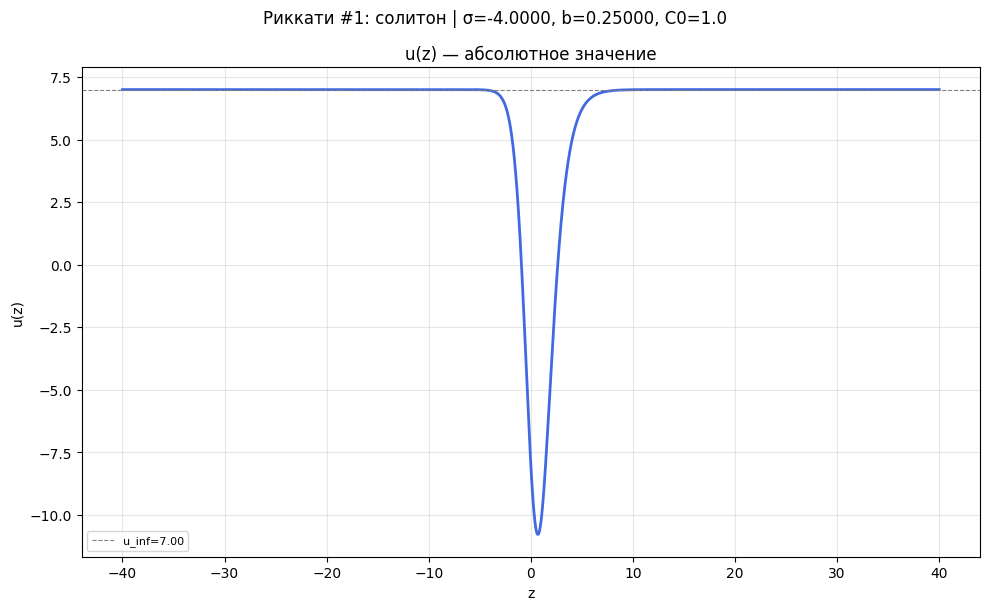

<IPython.core.display.Math object>

1. Найти решения Риккати
2. Найти решения Вейерштрасса
3. Построить график Риккати (по номеру)
4. Построить график Вейерштрасса (по номеру)
5. Построить все графики
0. Выход
Выбор: 4
Номер решения: 1

Введите входные параметры для Вейерштрасса:
  C0 [по умолч. 1.0]: 
  C1 [по умолч. 0.0]: 
  a  [по умолч. 1.0]: 

Решение #1: σ=-4.0000, a=1.0000, b=0.000000, c=-0.016204
A0=7.0000, A1=-60.0000, A2=60.0000
Корни кубического: ['-0.1066']
Не найдено 3 вещественных корня, пропускаем


<IPython.core.display.Math object>

1. Найти решения Риккати
2. Найти решения Вейерштрасса
3. Построить график Риккати (по номеру)
4. Построить график Вейерштрасса (по номеру)
5. Построить все графики
0. Выход
Выбор: 5

Введите C0 для Риккати [по умолч. 1.0]: 99

 Коэффициенты решения Риккати #1
A0 = -0.0833333333333333*A1*sigma - 0.0378289473684211*sigma**3 + 0.355263157894737*sigma + 99.0
A1 = -30
A2 = -15*sigma
A3 = 120
C1 = A1**3/2400 + 7*A1**2/240 - A1/4 + 4860.0
b = 1/4
sigma = -4

Построение графика #1: σ=-4.0000, b=0.250000, C0=99.0


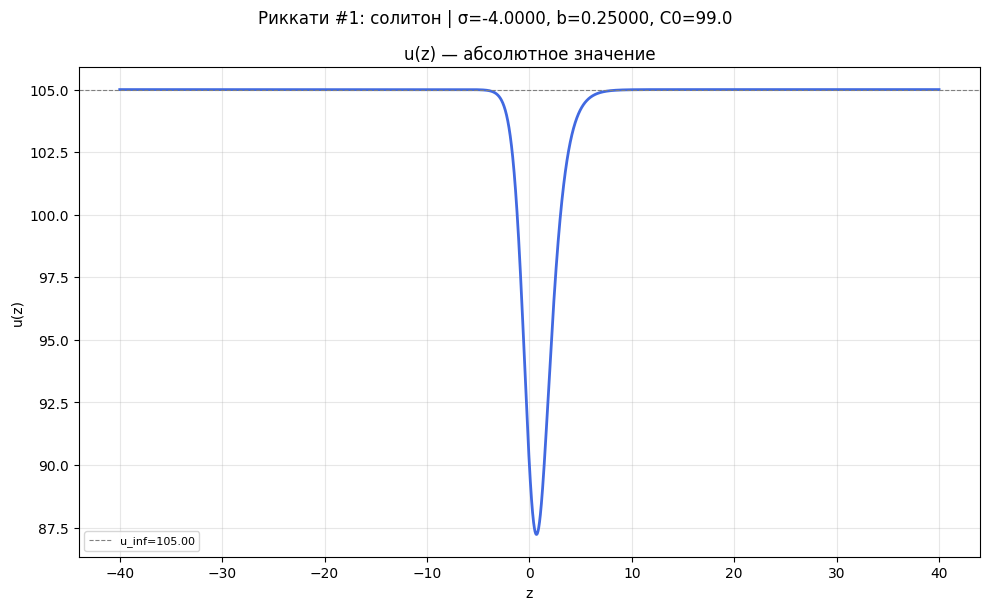


 Коэффициенты решения Риккати #2
A0 = -0.0833333333333333*A1*sigma - 0.0378289473684211*sigma**3 + 0.355263157894737*sigma + 99.0
A1 = -30
A2 = -15*sigma
A3 = 120
C1 = A1**3/2400 + 7*A1**2/240 - A1/4 + 4860.0
b = 1/4
sigma = 4

Построение графика #2: σ=4.0000, b=0.250000, C0=99.0


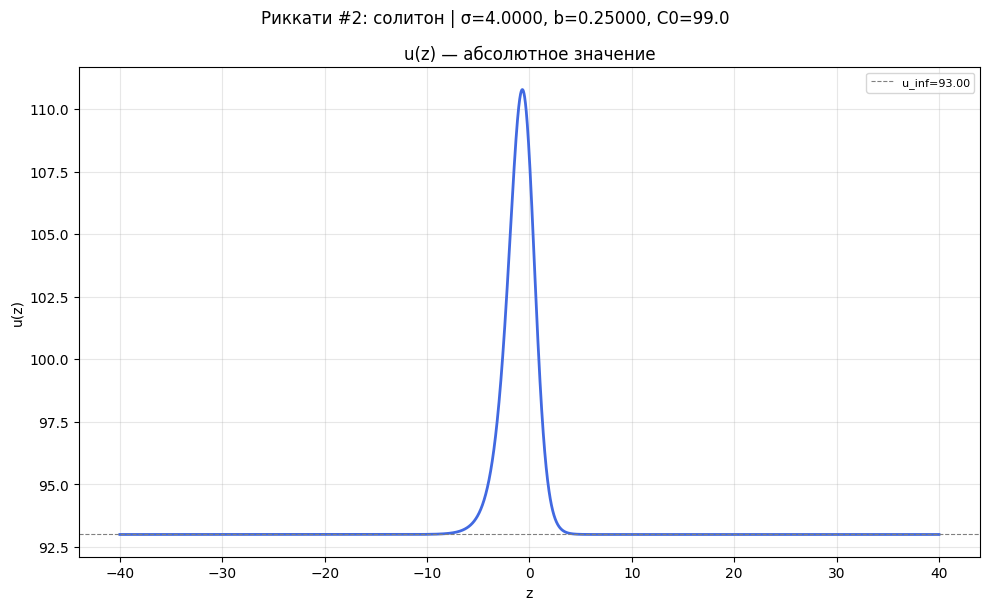


 Коэффициенты решения Риккати #3
A0 = -0.0833333333333333*A1*sigma - 0.0378289473684211*sigma**3 + 0.355263157894737*sigma + 99.0
A1 = -270/19
A2 = -15*sigma
A3 = 120
C1 = 0.000416666666666667*A1**3 - 0.00592105263157895*A1**2 - 0.0934903047091413*A1 + 4900.84115760315
b = 11/76
sigma = 0

Построение графика #3: σ=0.0000, b=0.144737, C0=99.0


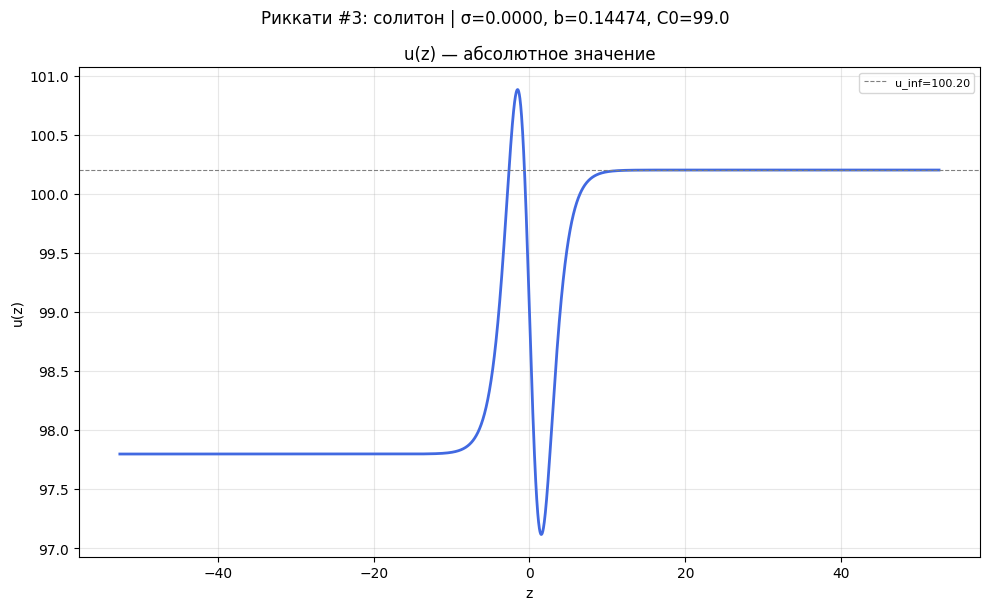


 Коэффициенты решения Риккати #4
A0 = -0.0833333333333333*A1*sigma - 0.0378289473684211*sigma**3 + 0.355263157894737*sigma + 99.0
A1 = 90/47
A2 = -15*sigma
A3 = 120
C1 = 0.000416666666666667*A1**3 + 0.00345744680851064*A1**2 - 0.00984608420099593*A1 + 4900.4859135259
b = 1/188
sigma = -12*sqrt(47)/47

Построение графика #4: σ=-1.7504, b=0.005319, C0=99.0


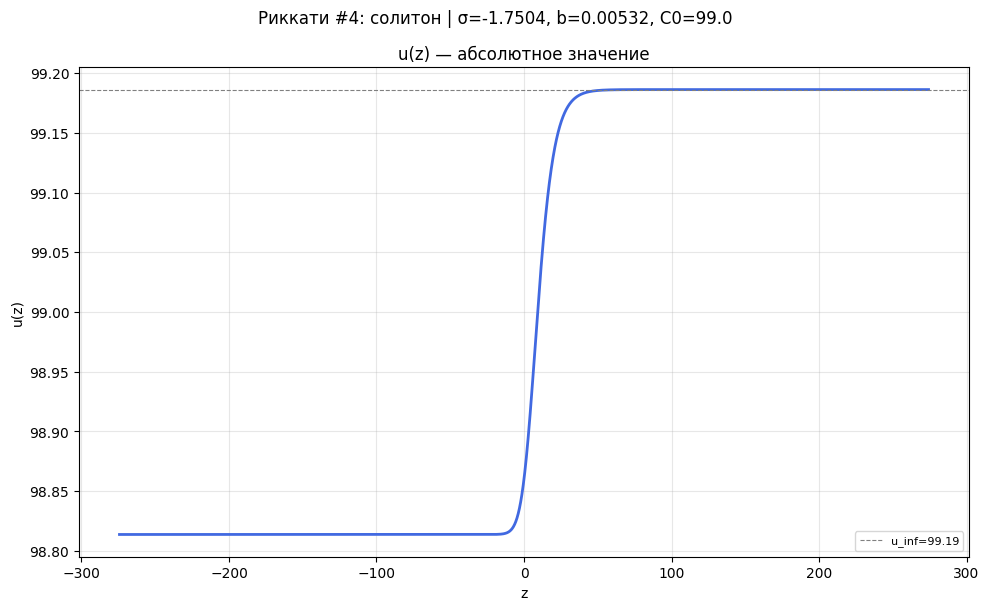


 Коэффициенты решения Риккати #5
A0 = -0.0833333333333333*A1*sigma - 0.0378289473684211*sigma**3 + 0.355263157894737*sigma + 99.0
A1 = 90/47
A2 = -15*sigma
A3 = 120
C1 = 0.000416666666666667*A1**3 + 0.00345744680851064*A1**2 - 0.00984608420099593*A1 + 4900.4859135259
b = 1/188
sigma = 12*sqrt(47)/47

Построение графика #5: σ=1.7504, b=0.005319, C0=99.0


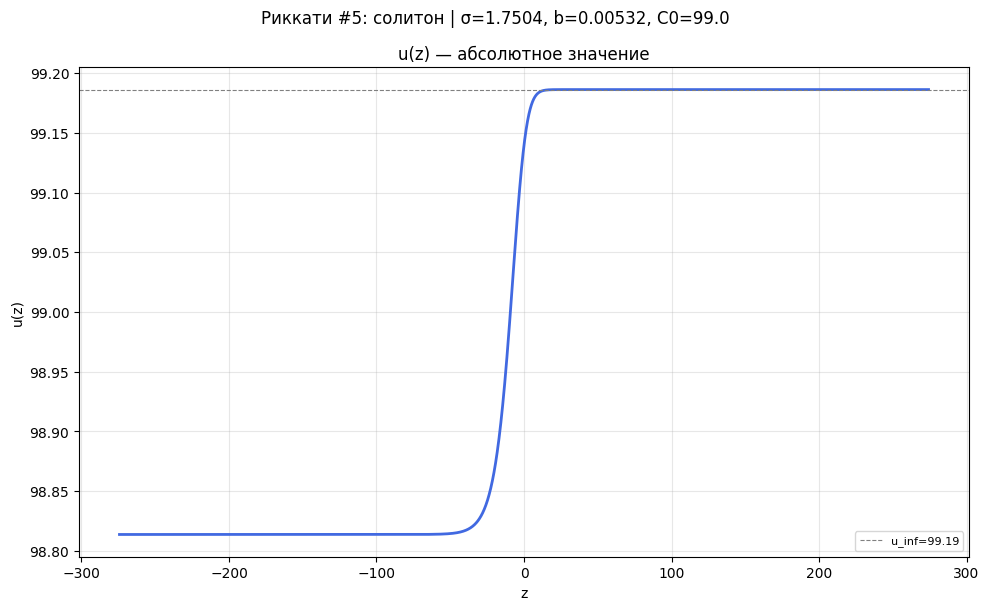


 Коэффициенты решения Риккати #6
A0 = -0.0833333333333333*A1*sigma - 0.0378289473684211*sigma**3 + 0.355263157894737*sigma + 99.0
A1 = 150/73
A2 = -15*sigma
A3 = 120
C1 = 0.000416666666666667*A1**3 + 0.00450913242009132*A1**2 - 0.0127134546819291*A1 + 4900.49305942928
b = 1/292
sigma = -16*sqrt(73)/73

Построение графика #6: σ=-1.8727, b=0.003425, C0=99.0


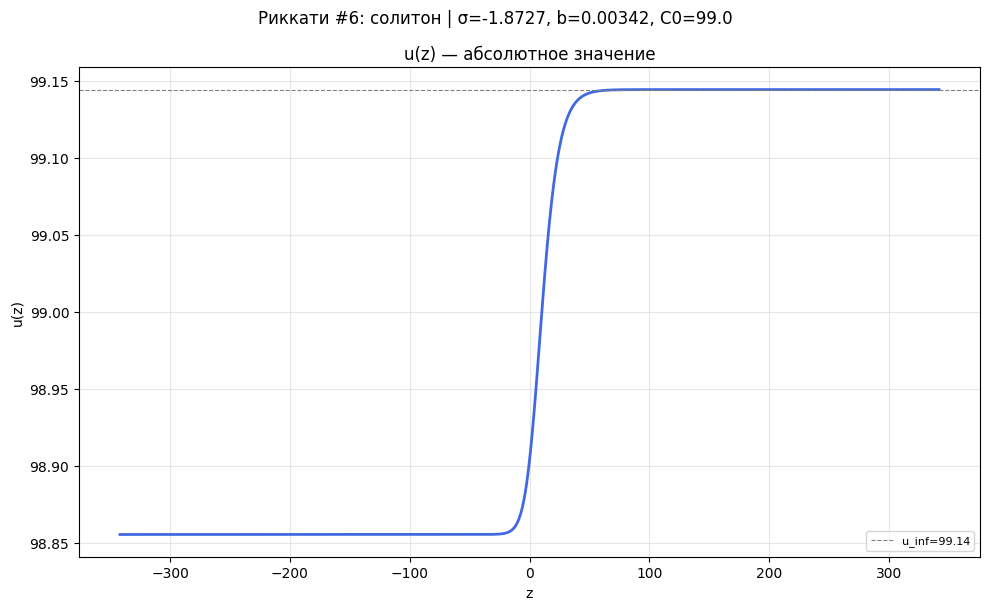


 Коэффициенты решения Риккати #7
A0 = -0.0833333333333333*A1*sigma - 0.0378289473684211*sigma**3 + 0.355263157894737*sigma + 99.0
A1 = 150/73
A2 = -15*sigma
A3 = 120
C1 = 0.000416666666666667*A1**3 + 0.00450913242009132*A1**2 - 0.0127134546819291*A1 + 4900.49305942928
b = 1/292
sigma = 16*sqrt(73)/73

Построение графика #7: σ=1.8727, b=0.003425, C0=99.0


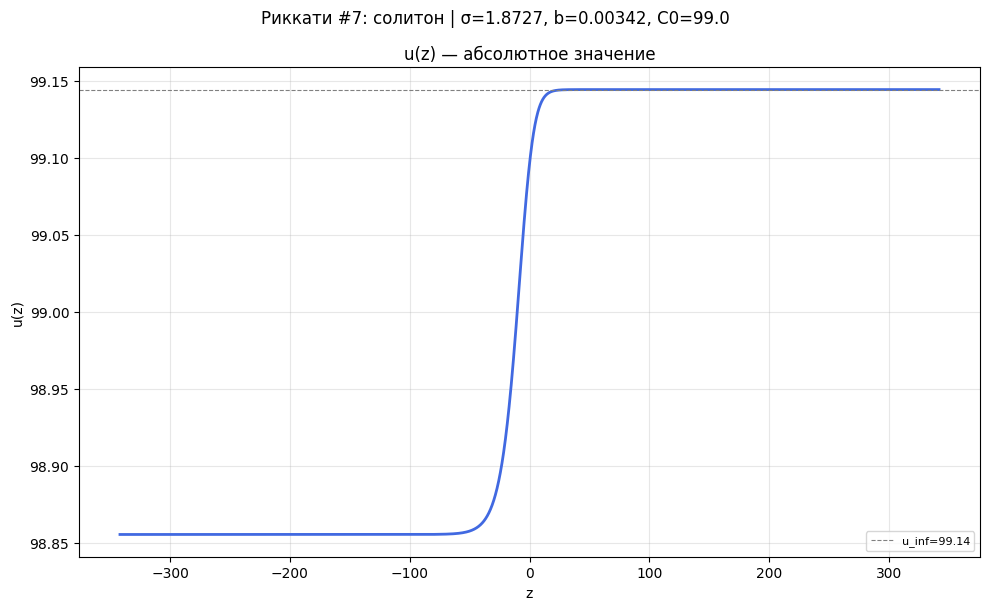


 Коэффициенты решения Риккати #8
A0 = -0.0833333333333333*A1*sigma - 0.0378289473684211*sigma**3 + 0.355263157894737*sigma + 99.0
A1 = 90/19
A2 = -15*sigma
A3 = 120
C1 = 0.000416666666666667*A1**3 - 0.00328947368421053*A1**2 + 0.0477839335180055*A1 + 4900.36878553725
b = -1/76
sigma = 0

Построение графика #8: σ=0.0000, b=-0.013158, C0=99.0


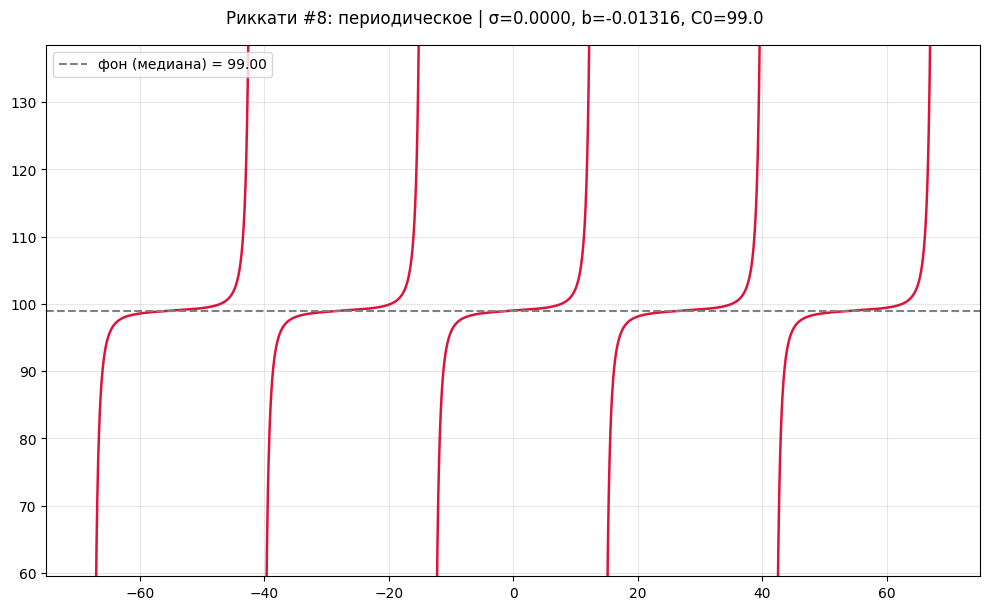


 Коэффициенты решения Риккати #9
A0 = -0.0833333333333333*A1*sigma - 0.0378289473684211*sigma**3 + 0.355263157894737*sigma + 99.0
A1 = 30
A2 = -15*sigma
A3 = 120
C1 = A1**3/2400 + 3*A1**2/80 + A1/4 + 4840.0
b = -1/4
sigma = -4

Построение графика #9: σ=-4.0000, b=-0.250000, C0=99.0


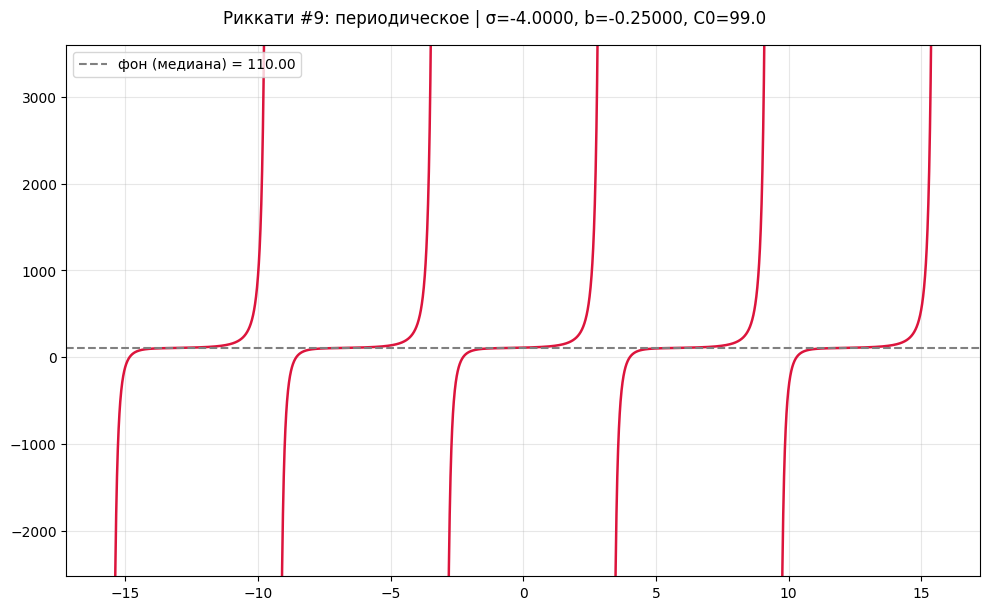


 Коэффициенты решения Риккати #10
A0 = -0.0833333333333333*A1*sigma - 0.0378289473684211*sigma**3 + 0.355263157894737*sigma + 99.0
A1 = 30
A2 = -15*sigma
A3 = 120
C1 = A1**3/2400 + 3*A1**2/80 + A1/4 + 4840.0
b = -1/4
sigma = 4

Построение графика #10: σ=4.0000, b=-0.250000, C0=99.0


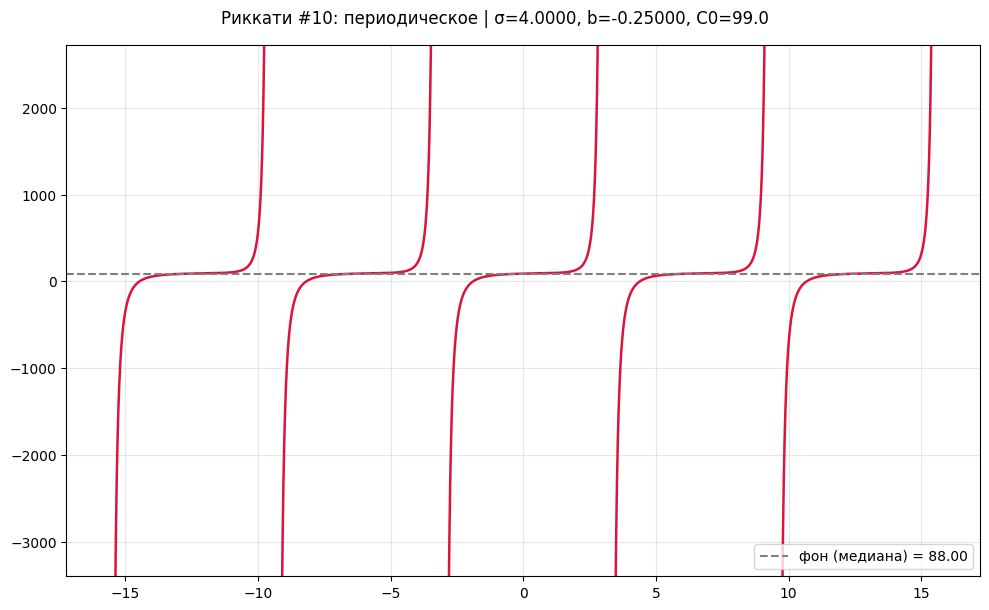


Параметры для Вейерштрасса:
  C0 [по умолч. 1.0]: 1
  C1 [по умолч. 0.0]: -13
  a  [по умолч. 1.0]: 1

Решение #1: σ=-4.0000, a=1.0000, b=0.000000, c=-0.004167
A0=7.0000, A1=-60.0000, A2=60.0000
Корни кубического: ['0.2304', '0.0778', '-0.0581']


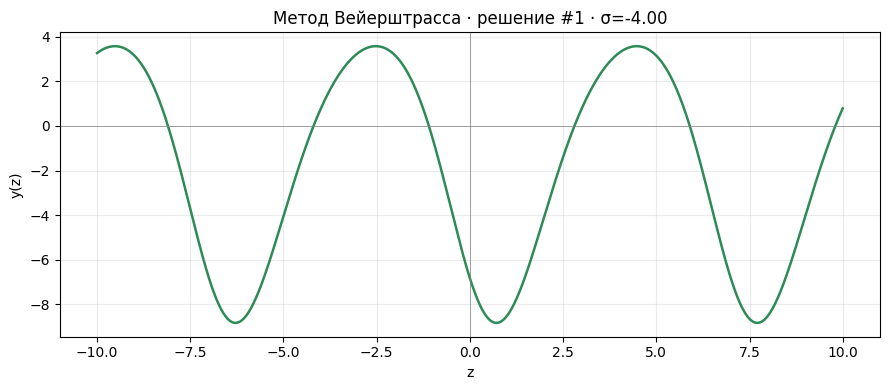


Решение #2: σ=4.0000, a=1.0000, b=0.000000, c=-0.004167
A0=-5.0000, A1=60.0000, A2=60.0000
Корни кубического: ['0.2304', '0.0778', '-0.0581']


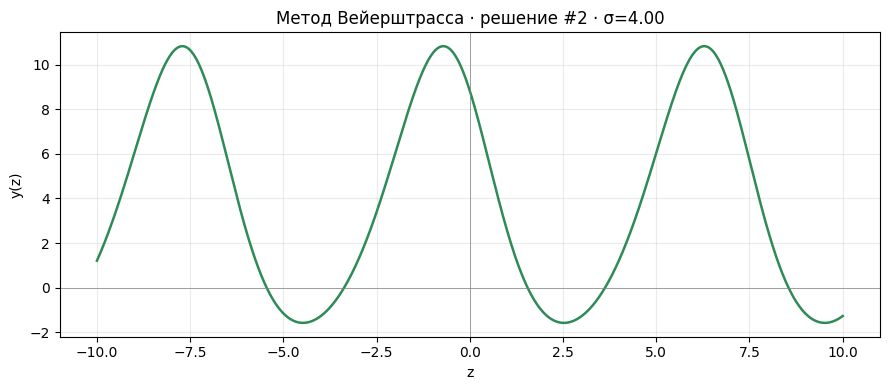

<IPython.core.display.Math object>

1. Найти решения Риккати
2. Найти решения Вейерштрасса
3. Построить график Риккати (по номеру)
4. Построить график Вейерштрасса (по номеру)
5. Построить все графики
0. Выход
Выбор: 0

Завершение работы


In [ ]:
# Менюшка

def main():
    riccati_sols, weier_sols = [], []
    show_ks_equation()

    while True:
        print("="*70)
        show_math(r"\text{\textbf{МЕНЮ РЕШАТЕЛЯ}}")
        print("="*70)
        print("1. Найти решения Риккати")
        print("2. Найти решения Вейерштрасса")
        print("3. Построить график Риккати (по номеру)")
        print("4. Построить график Вейерштрасса (по номеру)")
        print("5. Построить все графики")
        print("0. Выход")
        choice = input("Выбор: ")

        if choice == '1':
            riccati_sols = solve_riccati_symbolic()
            print("="*30)
            show_math(r"\text{\textbf{Метод Риккати: подстановка}} \quad y(z) = A_0 + A_1 Y + A_2 Y^2 + A_3 Y^3, \quad Y' = b - Y^2")
            display_solutions(riccati_sols, "Риккати", riccati_extra_display)

        elif choice == '2':
            weier_sols = solve_weierstrass_sequential()
            show_math(r"\text{\textbf{Метод Вейерштрасса: подстановка}} \quad y(z) = A_0 + A_1 R + A_2 R', \quad (R')^2 = -4R^3 + aR^2 + 2bR + c")
            display_solutions(weier_sols, "Вейерштрасс", weierstrass_extra_display)

        elif choice == '3':
            if not riccati_sols:
                print("Сначала выполните пункт 1.")
            else:
                try:
                    idx = int(input("Номер решения: ")) - 1
                    if 0 <= idx < len(riccati_sols):
                        plot_riccati(riccati_sols[idx], idx+1, C0_val=None)
                    else:
                        print(f"Номер должен быть от 1 до {len(riccati_sols)}.")
                except ValueError:
                    print("Введите целое число.")

        elif choice == '4':
            if not weier_sols:
                print("Сначала выполните пункт 2.")
            else:
                try:
                    idx = int(input("Номер решения: ")) - 1
                    if 0 <= idx < len(weier_sols):
                        print("\nВведите входные параметры для Вейерштрасса:")
                        c0_in = input("  C0 [по умолч. 1.0]: ").strip()
                        c1_in = input("  C1 [по умолч. 0.0]: ").strip()
                        a_in  = input("  a  [по умолч. 1.0]: ").strip()
                        C0_v = float(c0_in) if c0_in else 1.0
                        C1_v = float(c1_in) if c1_in else 0.0
                        a_v  = float(a_in)  if a_in  else 1.0
                        plot_weierstrass_solution(weier_sols[idx], idx+1,
                                                  C0_val=C0_v, a_val=a_v, C1_val=C1_v)
                    else:
                        print(f"Номер должен быть от 1 до {len(weier_sols)}.")
                except ValueError:
                    print("Введите целое число.")

        elif choice == '5':
            if riccati_sols:
                c0_in = input("\nВведите C0 для Риккати [по умолч. 1.0]: ").strip()
                C0_r = float(c0_in) if c0_in else 1.0
                for i, s in enumerate(riccati_sols, 1):
                    plot_riccati(s, i, C0_val=C0_r)

            if weier_sols:
                print("\nПараметры для Вейерштрасса:")
                c0_w = input("  C0 [по умолч. 1.0]: ").strip() or "1.0"
                c1_w = input("  C1 [по умолч. 0.0]: ").strip() or "0.0"
                a_w  = input("  a  [по умолч. 1.0]: ").strip() or "1.0"
                for i, s in enumerate(weier_sols, 1):
                    plot_weierstrass_solution(s, i, C0_val=float(c0_w), a_val=float(a_w), C1_val=float(c1_w))

        elif choice == '0':
            print("\nЗавершение работы")
            break

if __name__ == '__main__':
    main()